# 5.1.2 把抽样变成可比较的重复实验

## 学习目标与先修知识

能区分一组样本、重复实验和随机种子（random seed）；比较样本量改变后的频率波动，区分组平均与合并频率。

先修：上一节的二值分布（distribution）与概率（probability）；列表、循环与算术平均。经验分位数（empirical quantile）在本节解释。 [复习上一节](01-事件分布与一次实现.ipynb)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

若真实活跃概率固定为 0.3，抽 20 个细胞与抽 200 个细胞会得到同样稳定的比例吗？先重复整个抽样过程，再讨论频率，而不挑一条好看的结果。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN, GRAY = '#008bfb', '#ff0051', '#009e73', '#555555'

## 初步实验

In [2]:
rng=np.random.Generator(np.random.PCG64(5102))
display(Markdown(show_table(['抽样数','一次成功数','一次频率'],[(n,int((x:=rng.random(n)<.3).sum()),float(x.mean())) for n in [20,200]])))

| 抽样数 | 一次成功数 | 一次频率 |
| --- | --- | --- |
| 20 | 6 | 0.3 |
| 200 | 60 | 0.3 |

## 模型假设

每个细胞按 p=0.3 独立抽样，同一组没有共同环境扰动。样本量分别取 20、200，每种做 B=200 次独立重复，随机种子为 51020。固定种子便于复现整组实验；各次重复使用不同的抽样序列。

## 数学解释与推导

二值变量的成功频率为 $\hat p=\sum_{i=1}^n X_i/n$，它是从样本计算出的统计量（statistic）。固定 p 仍会产生不同的 $\hat p$。一次实验有 n 个观察；重复次数 B 表示重新抽 n 个观察的次数，两者不能混成一个量。

本节把 200 个频率按大小排序，用 5%、50%、95% 经验分位数摘要：例如 50% 是中间位置，分位点落在两个样本间时采用 NumPy 默认线性插值。5%—95% 范围描述重复频率的散布，不直接称作未知参数（parameter）的置信区间（confidence interval）。增加 B 是更稳定地描绘这种散布；增加 n 才改变每次频率的抽样机制。频率波动为何通常随 n 缩小，将在 5.2.1 用方差（variance）推导。

不同大小的组有两种问题：等权组平均 $(1/B)\sum_b\hat p_b$ 把每组当一个单位；合并频率 $\sum_b n_b\hat p_b/\sum_b n_b$ 把每个细胞当一个单位。组大小不等时二者可不同。

## 核心实现

把公式中的量和顺序写成可检查的计算。

In [3]:
def group_frequencies(groups):
    frequencies = [sum(group)/len(group) for group in groups]
    return frequencies, sum(frequencies)/len(groups), sum(map(sum, groups))/sum(map(len, groups))


def demonstration_uniforms(seed, size):
    # A small explicitly specified generator for cross-language demonstrations.
    # Statistical experiments below use NumPy PCG64 instead.
    state = seed
    values = []
    for _ in range(size):
        state = (1664525*state+1013904223) % (2**32)
        values.append(state/(2**32))
    return values

## 对照实验

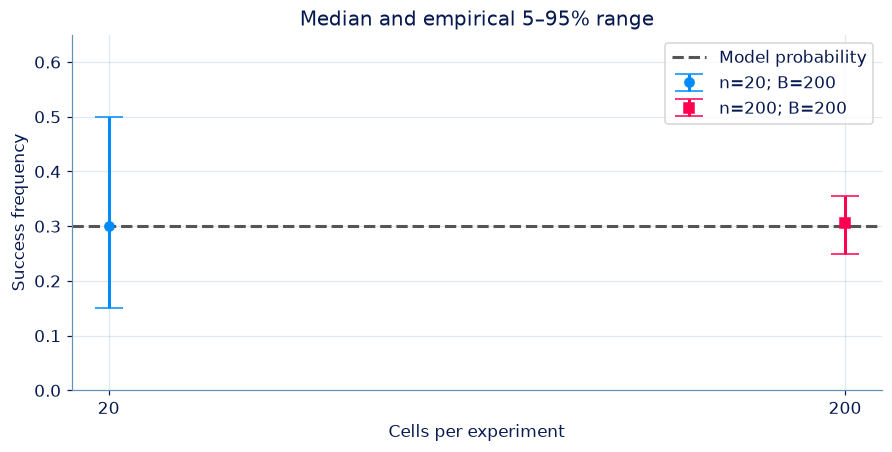

| n | 平均频率 | 5% | 50% | 95% |
| --- | --- | --- | --- | --- |
| 20 | 0.3145 | 0.15 | 0.3 | 0.5 |
| 200 | 0.302225 | 0.24975 | 0.305 | 0.355 |

根种子 51020 ；B= 200 ；PCG64；NumPy 2.5.3
不等组汇总： ([0.5, 0.75], 0.625, 0.6666666666666666)


In [4]:
sizes=[20,200];repeats=200;root_seed=51020
streams=np.random.SeedSequence(root_seed).spawn(len(sizes)*repeats)
frequencies=[]
for j,n in enumerate(sizes):
    frequencies.append(np.array([np.mean(np.random.Generator(np.random.PCG64(streams[j*repeats+b])).random(n)<.3) for b in range(repeats)]))
fig,ax=plt.subplots()
for j,(n,values) in enumerate(zip(sizes,frequencies)):
    lo,med,hi=np.quantile(values,[.05,.5,.95])
    ax.errorbar(n,med,yerr=[[med-lo],[hi-med]],fmt=['o','s'][j],color=[BLUE,PINK][j],capsize=9,label=f'n={n}; B=200')
ax.axhline(.3,color=GRAY,ls='--',label='Model probability')
ax.set(xlabel='Cells per experiment',ylabel='Success frequency',ylim=(0,.65),xticks=sizes,title='Median and empirical 5–95% range');ax.legend();plt.show()
display(Markdown(show_table(['n','平均频率','5%','50%','95%'],[(n,float(v.mean()),*np.quantile(v,[.05,.5,.95])) for n,v in zip(sizes,frequencies)])))
print('根种子',root_seed,'；B=',repeats,'；PCG64；NumPy',np.__version__)
print('不等组汇总：',group_frequencies([[1,0],[1,1,1,0]]))

## 结果解释

图中大样本组的频率分布更集中，依然有波动；单次大样本也可能比某一次小样本离 0.3 更远。

### 独立核对

先用可手算的不等组核对频率的分母，再比较独立抽样与重复同一串数得到的结果。

In [5]:
assert all(np.all((v>=0)&(v<=1)) for v in frequencies)
f,gm,pooled=group_frequencies([[1,0],[1,1,1,0]])
np.testing.assert_allclose([gm,pooled],[.625,2/3])
a=np.random.Generator(np.random.PCG64(7)).random(8)
b=np.random.Generator(np.random.PCG64(7)).random(8)
assert np.array_equal(a,b)
assert demonstration_uniforms(0,2)==[1013904223/2**32,1196435762/2**32]
print('频率范围、两种权重及重复种子的复现性质一致。')

频率范围、两种权重及重复种子的复现性质一致。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/05-01-从重复实验建立概率/explore/)：改变一个条件，比较实现、分布与理论参照，再返回完整推导。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：不同大小实验组怎样汇总

若干组独立细胞观察已给定，每个数是 0 或 1。计算各组成功频率、各组频率的等权平均，以及合并所有细胞的成功频率。

**函数与代码模板**

```python
def solve(
    groups: list[list[int]],
) -> tuple[list[float], float, float]:
    # 依据题目规则计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `groups` | `list[list[int]]` | 外层为实验组；内层为该组二值观察。 | 1 |

**返回值**

按以下顺序返回元组：(frequencies, group_mean, pooled_frequency)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `frequencies` | `list[float]` | 按组顺序排列的成功频率。 | 1 |
| `group_mean` | `float` | 对各组频率等权平均。 | 1 |
| `pooled_frequency` | `float` | 全部成功次数除以全部观察次数。 | 1 |

**计算规则**

每组频率=sum(group)/len(group)。后两项的权重不同，严格按各自定义计算。

**约束与边界**

- 所有数值有限；不修改输入（input）列表。
- 1—20 组，每组 1—100 个数，均为 0 或 1；无空组。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| groups | 外层为实验组；内层为该组二值观察。 | [[1, 0], [1, 1, 1, 0]] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
groups = [[1, 0], [1, 1, 1, 0]]

result = solve(groups)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| frequencies | 按组顺序排列的成功频率。 | [0.5, 0.75] | 1 |
| group_mean | 对各组频率等权平均。 | 0.625 | 1 |
| pooled_frequency | 全部成功次数除以全部观察次数。 | ≈ 0.6666667 | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0.5, 0.75], 0.625, 0.6666666666666666)
```

**样例解释**

两组频率为 0.5、0.75；组平均 0.625，合并频率 4/6≈0.666667。较大组在合并统计中权重较大。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：不同大小实验组怎样汇总](http://127.0.0.1:8000/chapters/05-01-%E4%BB%8E%E9%87%8D%E5%A4%8D%E5%AE%9E%E9%AA%8C%E5%BB%BA%E7%AB%8B%E6%A6%82%E7%8E%87/practice/?question=p05-frequencies)

### 第 2 题 · 单项选择题：同一个种子不是新增证据

每次都重新创建相同种子的生成器，抽 50 个数，重复 200 次，发现每组均值完全相同。哪项正确？

- **A.** 这只是同一伪随机序列的复现，不能当作 200 次独立重复。
- **B.** 增加到 2000 次就能修复独立性。
- **C.** 种子只影响画图，不影响样本。
- **D.** 证明抽样方差（variance）为零。

[作答：同一个种子不是新增证据](http://127.0.0.1:8000/chapters/05-01-%E4%BB%8E%E9%87%8D%E5%A4%8D%E5%AE%9E%E9%AA%8C%E5%BB%BA%E7%AB%8B%E6%A6%82%E7%8E%87/practice/?question=p05-seed-repeats)

### 第 3 题 · 多项选择题：重复频率的范围说明什么

200 次重新抽样各 20 个细胞，展示各组频率的 5%—95% 经验分位范围。哪些正确？

- **A.** 增大每组样本量通常缩小频率波动，但一次结果不保证更接近真值。
- **B.** 分位范围会受到有限重复次数影响。
- **C.** 这是该设计下有限重复的频率波动摘要。
- **D.** 无需进一步定义，就能称为未知概率（probability）的 90% 置信区间（confidence interval）。

[作答：重复频率的范围说明什么](http://127.0.0.1:8000/chapters/05-01-%E4%BB%8E%E9%87%8D%E5%A4%8D%E5%AE%9E%E9%AA%8C%E5%BB%BA%E7%AB%8B%E6%A6%82%E7%8E%87/practice/?question=p05-repeat-band)

### 第 4 题 · 单项选择题：怎样更接近独立重复

目标是比较固定活跃概率（probability）下的独立二值观察。哪一设计最符合？

- **A.** 每组先随机改变活跃概率却仍声称固定概率。
- **B.** 复制一个细胞的标签 100 次。
- **C.** 反复读取同一个已保存数组（array）。
- **D.** 各细胞按同一概率独立抽样，重复实验使用派生的不同随机流。

[作答：怎样更接近独立重复](http://127.0.0.1:8000/chapters/05-01-%E4%BB%8E%E9%87%8D%E5%A4%8D%E5%AE%9E%E9%AA%8C%E5%BB%BA%E7%AB%8B%E6%A6%82%E7%8E%87/practice/?question=p05-shared-environment)

**进一步阅读**

[MIT 6.041 讲义](https://ocw.mit.edu/courses/6-041-probabilistic-systems-analysis-and-applied-probability-fall-2010/pages/lecture-notes/)：第 5、19 讲：样本摘要与频率极限。

[NumPy 随机子流文档](https://numpy.org/doc/stable/reference/random/parallel.html)：SeedSequence.spawn 的可复现派生。伪随机子流用来近似模型中的独立抽样，不等同于物理独立性的证明。